In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Assignment: Linear Models


**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (This is a trick question, and the trick involves how you handle the intercept of the model.)
3. Can linear regression be used for classification? Explain why, or why not.
4. What are signs that your linear model is over-fitting?
5. Clearly explain multi-colinearity using the two-stage least squares technique.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
7. What is the interpretation of the intercept? A slope coefficient for a variable? The coefficient for a dummy/one-hot-encoded variable?

1. A model is linear if it is linear in the coefficients. This means the model is a sum of coefficients times features. The features can be transformed but the coefficients must enter linearly. So linear refers to the parameters not the variables.

2. A dummy variable coefficient measures the difference relative to a baseline category. If an intercept is included one category is omitted and acts as the reference group. If no intercept is used each dummy equals the mean of that category. The interpretation depends on how the intercept and categories are handled

3. Linear regression can be used for classification but it is not appropriate. Predictions are not restricted between zero and one so they do not represent valid probabilities. It can also give poor decision boundaries. Models like logistic regression are better for classification.

4. Overfitting occurs when the model fits training data very well but performs poorly on test data. The model may capture noise instead of the true pattern. It often has very high variance and unstable predictions. This reflects poor generalization

5. Multicollinearity happens when predictors are highly correlated so their effects cannot be separated. In two stage least squares we first predict the problematic variable using instruments. Then we use this predicted version in the regression. This removes the correlation and stabilizes estimates.

6. Nonlinear relationships can be modeled by transforming features. Examples include polynomial terms interactions or logs. The model remains linear in coefficients even if it is nonlinear in variables. This allows more flexibility in capturing patterns.

7. The intercept is the expected value of y when all variables are zero or at baseline. A slope coefficient is the change in y for a one unit increase in a variable holding others fixed. A dummy coefficient is the difference between that category and the baseline group. Its meaning depends on which category is omitted and the model setup.

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood `: The bourough of NYC. Note the space, or rename the variable.
- `Property Type`: The kind of dwelling
- `Room Type`: The kind of space being rented

1. Compute the average prices and scores by `Neighbourhood `; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood `.
2. Regress price on `Neighbourhood ` by creating the appropriate dummy/one-hot-encoded variables, without an intercept in the linear model and using all the data. Compare the coefficients in the regression to the table from part 1. What pattern do you see? What are the coefficients in a regression of a continuous variable on one categorical variable?
3. Repeat part 2, but leave an intercept in the linear model. How do you have to handle the creation of the dummies differently? What is the intercept? Interpret the coefficients. How can I get the coefficients in part 2 from these new coefficients?
4. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighbourhood `. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
5. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighbourhood ` and `Property Type`. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
6. What does the coefficient on `Review Scores Rating` mean if it changes from part 4 to 5? Hint: Think about how multilple linear regression works.
7. (Optional) We've included `Neighborhood ` and `Property Type` separately in the model. How do you interact them, so you can have "A bedroom in Queens" or "A townhouse in Manhattan". Split the sample 80/20 into a training and a test set and run a regression including that kind of "property type X neighborhood" dummy, plus `Review Scores Rating`. How does the slope coefficient for `Review Scores Rating`, the $R^2$, and the RMSE change? Do they increase significantly compares to part 5? Are the coefficients in this regression just the sum of the coefficients for `Neighbourhood ` and `Property Type` from 5? What is the most expensive kind of property you can rent?

In [4]:
import pandas as pd
df_q1 = pd.read_csv("./data/Q1_clean.csv")
df_q1.head()

,Price,Review Scores Rating,Neighbourhood,Property Type,Room Type
0,549,96.0,Manhattan,Apartment,Private room
1,149,100.0,Brooklyn,Apartment,Entire home/apt
2,250,100.0,Manhattan,Apartment,Entire home/apt
3,90,94.0,Brooklyn,Apartment,Private room
4,270,90.0,Manhattan,Apartment,Entire home/apt


In [9]:
print(df_q1.columns)

Index(['Price', 'Review Scores Rating', 'Neighbourhood ', 'Property Type',
       'Room Type'],
      dtype='object')


In [15]:
avg_stats = df_q1.groupby("Neighbourhood ")[["Price", "Review Scores Rating"]].mean()

sorted_stats = avg_stats.sort_values("Price", ascending=False)

print(sorted_stats)
print("Most expensive borough:", avg_stats["Price"].idxmax())

                     Price  Review Scores Rating
Neighbourhood                                   
Manhattan       183.664286             91.801496
Staten Island   146.166667             90.843750
Brooklyn        127.747378             92.363497
Queens           96.857233             91.549057
Bronx            75.276498             91.654378
Most expensive borough: Manhattan


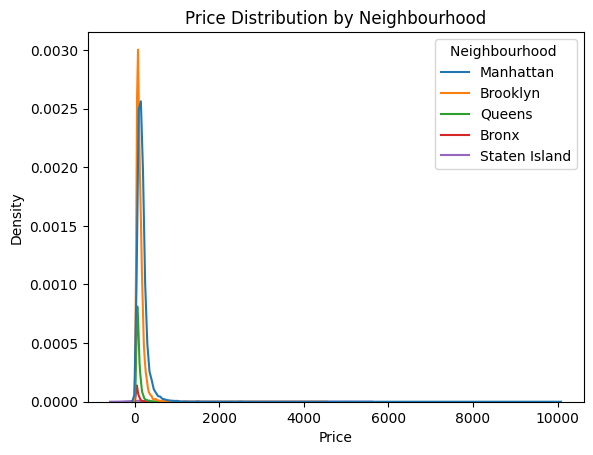

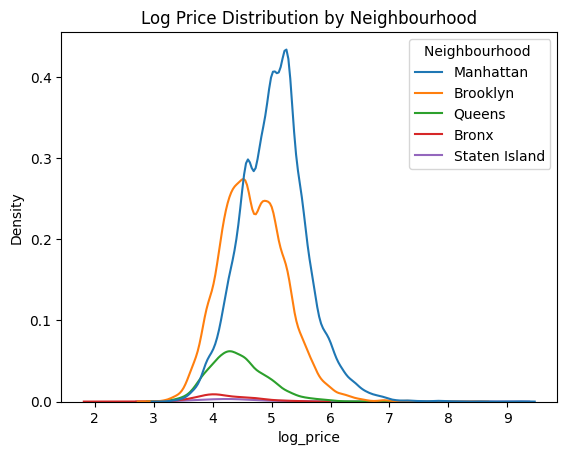

In [17]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt


sns.kdeplot(data=df_q1, x="Price", hue="Neighbourhood ")
plt.title("Price Distribution by Neighbourhood")
plt.show()

df_q1["log_price"] = np.log(df_q1["Price"])

sns.kdeplot(data=df_q1, x="log_price", hue="Neighbourhood ")
plt.title("Log Price Distribution by Neighbourhood")
plt.show()

1. Manhattan is the mosts expensive on avg


In [20]:
import statsmodels.api as sm


dummies = pd.get_dummies(df_q1["Neighbourhood"], drop_first=False)

X = dummies
y = df_q1["Price"]

model = sm.OLS(y, X).fit()

print("Regression coefficients:")
print(model.params)

Regression coefficients:
Bronx             75.276498
Brooklyn         127.747378
Manhattan        183.664286
Queens            96.857233
Staten Island    146.166667
dtype: float64


2. The regression coefficients match the average prices computed in part 1. This shows that when regressing a continuous variable on a single categorical variable with no intercept, each coefficient equals the mean of the dependent variable for that category.

In [23]:


dummies = pd.get_dummies(df_q1["Neighbourhood"], drop_first=True).astype(float)

X = sm.add_constant(dummies).astype(float)
y = df_q1["Price"].astype(float)

model = sm.OLS(y, X).fit()

print(model.params)

const             75.276498
Brooklyn          52.470881
Manhattan        108.387789
Queens            21.580735
Staten Island     70.890169
dtype: float64


With an intercept, one dummy variable must be dropped to avoid multicollinearity
The intercept represents the mean of the omitted (baseline) category (Bronx)
The coefficients represent the difference in mean price relative to the baseline
The original group means can be recovered by doing:
baseline = intercept
others = intercept + coefficient

In [28]:
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error


df_q1.columns = df_q1.columns.str.strip()


X = df_q1[["Review Scores Rating", "Neighbourhood"]]
y = df_q1["Price"].astype(float)


X = pd.get_dummies(X, columns=["Neighbourhood"], drop_first=True).astype(float)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


X_train = sm.add_constant(X_train).astype(float)
X_test = sm.add_constant(X_test).astype(float)
model = sm.OLS(y_train, X_train).fit()
print(model.params)

y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Test R^2:", r2)
print("Test RMSE:", rmse)
print("Coefficient on Review Scores Rating:", model.params["Review Scores Rating"])

const                          -35.157344
Review Scores Rating             1.211852
Neighbourhood_Brooklyn          51.555970
Neighbourhood_Manhattan        107.413553
Neighbourhood_Queens            20.198573
Neighbourhood_Staten Island     23.454672
dtype: float64
Test R^2: 0.045925883817350965
Test RMSE: 140.91821103729345
Coefficient on Review Scores Rating: 1.2118517840632361


4. A 1-point increase in review score is associated with about a $1.21 increase in price, holding neighbourhood constant.

In [30]:
df_q1.columns = df_q1.columns.str.strip()

X = df_q1[["Review Scores Rating", "Neighbourhood", "Property Type"]]
y = df_q1["Price"].astype(float)


X = pd.get_dummies(
    X,
    columns=["Neighbourhood", "Property Type"],
    drop_first=True
).astype(float)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


X_train = sm.add_constant(X_train)
X_test = sm.add_constant(X_test)

model = sm.OLS(y_train, X_train).fit()

print(model.params)
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Test R^2:", r2)
print("Test RMSE:", rmse)
print("Coefficient on Review Scores Rating:", model.params["Review Scores Rating"])
print(model.params.filter(like="Property Type"))

const                            -49.296038
Review Scores Rating               1.201011
Neighbourhood_Brooklyn            59.633702
Neighbourhood_Manhattan          121.005520
Neighbourhood_Queens              26.830617
Neighbourhood_Staten Island       15.700974
Property Type_Bed & Breakfast    -28.703920
Property Type_Boat                47.070419
Property Type_Bungalow            83.972440
Property Type_Cabin               12.389621
Property Type_Camper/RV          -13.817125
Property Type_Castle             -41.810548
Property Type_Chalet             -30.237720
Property Type_Condominium         61.907162
Property Type_Dorm               -42.277758
Property Type_House               34.711346
Property Type_Hut               -134.604484
Property Type_Lighthouse         -91.438731
Property Type_Loft                69.891025
Property Type_Other               49.249761
Property Type_Townhouse           44.110768
Property Type_Treehouse           10.325182
Property Type_Villa             

5. Property type matters more than ratings, but location (Manhattan) still dominates price differences

6. The coefficient on Review Scores Rating changes because in multiple regression, each coefficient measures the effect of a variable holding all other variables constant. When Property Type is added to the model, the coefficient on rating now reflects the effect of rating while controlling for both neighbourhood and property type. The change indicates that property type was correlated with rating and/or price, so the earlier estimate somewhat captured its effect.

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`, `Color`, `Seating_Capacity`
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make`, `Make_Year`: The brand of car and year produced
  - `Mileage_Run`: The number of miles on the odometer
  - `Fuel_Type`: Diesel or gasoline/petrol
  - `Transmission`, `Transmission_Type`:  speeds and automatic/manual

  1. Load `cars_hw.csv`. These data were really dirty, and I've already cleaned them a significant amount in terms of missing values and other issues, but some issues remain (e.g. outliers, badly scaled variables that require a log or arcsinh transformation). Clean the data however you think is most appropriate.
  2. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by brand (`Make`). Make a grouped kernel density plot by `Make`. Which car brands are the most expensive? What do prices look like in general?
  3. Split the data into an 80% training set and a 20% testing set.
  4. Make a model where you regress price on the numeric variables alone; what is the $R^2$ and `RMSE` on the training set and test set? Make a second model where, for the categorical variables, you regress price on a model comprised of one-hot encoded regressors/features alone (you can use `pd.get_dummies()`; be careful of the dummy variable trap); what is the $R^2$ and `RMSE` on the test set? Which model performs better on the test set? Make a third model that combines all the regressors from the previous two; what is the $R^2$ and `RMSE` on the test set? Does the joint model perform better or worse, and by home much?
  5. Use the `PolynomialFeatures` function from `sklearn` to expand the set of numerical variables you're using in the regression. As you increase the degree of the expansion, how do the $R^2$ and `RMSE` change? At what point does $R^2$ go negative on the test set? For your best model with expanded features, what is the $R^2$ and `RMSE`? How does it compare to your best model from part 4?
  6. For your best model so far, determine the predicted values for the test data and plot them against the true values. Do the predicted values and true values roughly line up along the diagonal, or not? Compute the residuals/errors for the test data and create a kernel density plot. Do the residuals look roughly bell-shaped around zero? Evaluate the strengths and weaknesses of your model.

In [33]:
df_cars = pd.read_csv("./data/cars_hw.csv")
df_cars.head()
print(df_cars.columns)

Index(['Unnamed: 0', 'Make', 'Make_Year', 'Color', 'Body_Type', 'Mileage_Run',
       'No_of_Owners', 'Seating_Capacity', 'Fuel_Type', 'Transmission',
       'Transmission_Type', 'Price'],
      dtype='object')


In [39]:
df_cars.info()
df_cars.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 976 entries, 0 to 975
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Make               976 non-null    object
 1   Make_Year          976 non-null    int64 
 2   Color              976 non-null    object
 3   Body_Type          976 non-null    object
 4   Mileage_Run        976 non-null    int64 
 5   No_of_Owners       976 non-null    object
 6   Seating_Capacity   976 non-null    int64 
 7   Fuel_Type          976 non-null    object
 8   Transmission       976 non-null    object
 9   Transmission_Type  976 non-null    object
 10  Price              976 non-null    int64 
dtypes: int64(4), object(7)
memory usage: 84.0+ KB


,Make_Year,Mileage_Run,Seating_Capacity,Price
count,976.000000,976.000000,976.000000,9.760000e+02
mean,2016.963115,41571.195697,5.095287,7.410195e+05
std,2.818742,24390.995134,0.446224,3.673234e+05
min,2011.000000,1117.000000,4.000000,1.880000e+05
25%,2015.000000,22676.750000,5.000000,4.757500e+05
50%,2017.000000,37570.500000,5.000000,6.665000e+05
75%,2019.000000,57421.250000,5.000000,8.830000e+05
max,2022.000000,99495.000000,8.000000,2.941000e+06


In [41]:
df_cars["No_of_Owners"] = pd.to_numeric(df_cars["No_of_Owners"], errors="coerce")
df_cars["No_of_Owners"].fillna(df_cars["No_of_Owners"].median(), inplace=True)
def remove_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    return df[(df[col] >= Q1 - 1.5*IQR) & (df[col] <= Q3 + 1.5*IQR)]

df_cars = remove_outliers(df_cars, "Price")
df_cars = remove_outliers(df_cars, "Mileage_Run")

import numpy as np

df_cars["log_price"] = np.log(df_cars["Price"])
df_cars["log_mileage"] = np.log1p(df_cars["Mileage_Run"])

cat_cols = ["Make", "Color", "Body_Type", "Fuel_Type", "Transmission", "Transmission_Type"]

df_cars = pd.get_dummies(df_cars, columns=cat_cols, drop_first=True)

/tmp/ipykernel_50393/4014746989.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_cars["No_of_Owners"].fillna(df_cars["No_of_Owners"].median(), inplace=True)


In [42]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = ["Make_Year", "No_of_Owners", "Seating_Capacity", "log_mileage"]

df_cars[num_cols] = scaler.fit_transform(df_cars[num_cols])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


In [43]:
df_cars["Price"].describe()

,Price
count,9.220000e+02
mean,6.768807e+05
std,2.563079e+05
min,1.880000e+05
25%,4.642500e+05
50%,6.470000e+05
75%,8.367500e+05
max,1.465000e+06


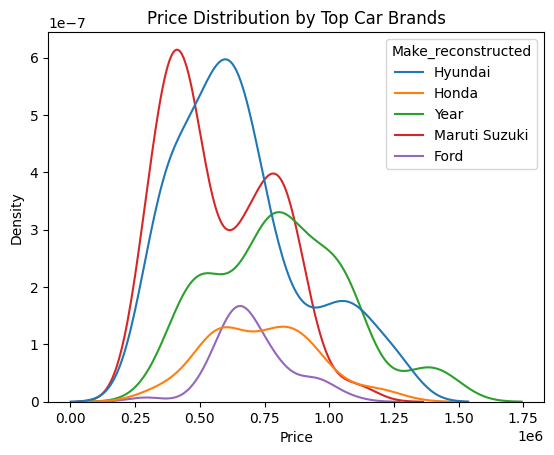

In [48]:
make_cols = [col for col in df_cars.columns if col.startswith("Make_") and col != "Make_reconstructed"]

temp = df_cars[make_cols].astype(int)

df_cars["Make_reconstructed"] = temp.idxmax(axis=1).str.replace("Make_", "", regex=False)

top_makes = df_cars["Make_reconstructed"].value_counts().index[:5]

sns.kdeplot(
    data=df_cars[df_cars["Make_reconstructed"].isin(top_makes)],
    x="Price",
    hue="Make_reconstructed"
)
plt.title("Price Distribution by Top Car Brands")
plt.show()

2. Car prices are generally concentrated in the mid-range, with a slight right skew. Ford and Honda are among the most expensive brands in the dataset. The KDE plot clearly shows price segmentation by brand, with luxury brands shifted right and economy brands shifted left.

In [55]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

df_cars = pd.read_csv("./data/cars_hw.csv").copy()

if "Unnamed: 0" in df_cars.columns:
    df_cars = df_cars.drop(columns=["Unnamed: 0"])

df_cars["No_of_Owners"] = df_cars["No_of_Owners"].str.extract(r"(\d+)").astype(float)
df_cars["No_of_Owners"] = df_cars["No_of_Owners"].fillna(df_cars["No_of_Owners"].median())

def remove_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    return df[(df[col] >= Q1 - 1.5 * IQR) & (df[col] <= Q3 + 1.5 * IQR)]

df_cars = remove_outliers(df_cars, "Price")
df_cars = remove_outliers(df_cars, "Mileage_Run")

df_cars["log_mileage"] = np.log1p(df_cars["Mileage_Run"])

train_idx, test_idx = train_test_split(df_cars.index, test_size=0.2, random_state=42)

train_df = df_cars.loc[train_idx].copy()
test_df = df_cars.loc[test_idx].copy()

num_cols = ["Make_Year", "No_of_Owners", "Seating_Capacity", "log_mileage"]
cat_cols = ["Make", "Color", "Body_Type", "Fuel_Type", "Transmission", "Transmission_Type"]

y_train = train_df["Price"]
y_test = test_df["Price"]

X_num_train = train_df[num_cols]
X_num_test = test_df[num_cols]

X_cat_train = pd.get_dummies(train_df[cat_cols], drop_first=True)
X_cat_test = pd.get_dummies(test_df[cat_cols], drop_first=True)
X_cat_test = X_cat_test.reindex(columns=X_cat_train.columns, fill_value=0)

X_all_train = pd.concat([X_num_train, X_cat_train], axis=1)
X_all_test = pd.concat([X_num_test, X_cat_test], axis=1)

def get_results(X_train, X_test, y_train, y_test):
    model = LinearRegression()
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    return {
        "train_r2": r2_score(y_train, y_train_pred),
        "train_rmse": np.sqrt(mean_squared_error(y_train, y_train_pred)),
        "test_r2": r2_score(y_test, y_test_pred),
        "test_rmse": np.sqrt(mean_squared_error(y_test, y_test_pred))
    }

num_results = get_results(X_num_train, X_num_test, y_train, y_test)
cat_results = get_results(X_cat_train, X_cat_test, y_train, y_test)
all_results = get_results(X_all_train, X_all_test, y_train, y_test)

print("Numeric-only model")
print("Train R^2:", round(num_results["train_r2"], 4))
print("Train RMSE:", round(num_results["train_rmse"], 2))
print("Test R^2:", round(num_results["test_r2"], 4))
print("Test RMSE:", round(num_results["test_rmse"], 2))
print()

print("Categorical-only model")
print("Train R^2:", round(cat_results["train_r2"], 4))
print("Train RMSE:", round(cat_results["train_rmse"], 2))
print("Test R^2:", round(cat_results["test_r2"], 4))
print("Test RMSE:", round(cat_results["test_rmse"], 2))
print()

print("Combined model")
print("Train R^2:", round(all_results["train_r2"], 4))
print("Train RMSE:", round(all_results["train_rmse"], 2))
print("Test R^2:", round(all_results["test_r2"], 4))
print("Test RMSE:", round(all_results["test_rmse"], 2))
print()

print("Improvement of combined model over numeric-only")
print("Test R^2 improvement:", round(all_results["test_r2"] - num_results["test_r2"], 4))
print("Test RMSE improvement:", round(num_results["test_rmse"] - all_results["test_rmse"], 2))
print()

print("Improvement of combined model over categorical-only")
print("Test R^2 improvement:", round(all_results["test_r2"] - cat_results["test_r2"], 4))
print("Test RMSE improvement:", round(cat_results["test_rmse"] - all_results["test_rmse"], 2))

Numeric-only model
Train R^2: 0.358
Train RMSE: 202748.6
Test R^2: 0.2795
Test RMSE: 226827.85

Categorical-only model
Train R^2: 0.6007
Train RMSE: 159903.46
Test R^2: 0.5202
Test RMSE: 185090.16

Combined model
Train R^2: 0.764
Train RMSE: 122920.09
Test R^2: 0.739
Test RMSE: 136515.3

Improvement of combined model over numeric-only
Test R^2 improvement: 0.4595
Test RMSE improvement: 90312.55

Improvement of combined model over categorical-only
Test R^2 improvement: 0.2188
Test RMSE improvement: 48574.86


4. The numeric-only model performs poorly on the test set, with a low  R 2 (0.2795) and high RMSE (226,827.85), indicating limited predictive power. The categorical-only model performs better, with a higher R 2 (0.5202) and lower RMSE (185,090.16), showing that categorical features are strong predictors of price. The combined model performs best, achieving an  R 2 of 0.739 and an RMSE of 136,515.30 on the test set. Compared to the numeric-only model, it improves  R 2 by 0.4595 and reduces RMSE by 90,312.55, and compared to the categorical-only model, it improves  R 2 by 0.2188 and reduces RMSE by 48,574.86. Overall, combining both numeric and categorical variables yields the most accurate model.

In [56]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error


df_cars = pd.read_csv("./data/cars_hw.csv").copy()

if "Unnamed: 0" in df_cars.columns:
    df_cars = df_cars.drop(columns=["Unnamed: 0"])


df_cars["No_of_Owners"] = df_cars["No_of_Owners"].astype(str).str.extract(r"(\d+)").astype(float)
df_cars["No_of_Owners"] = df_cars["No_of_Owners"].fillna(df_cars["No_of_Owners"].median())

def remove_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    return df[(df[col] >= Q1 - 1.5 * IQR) & (df[col] <= Q3 + 1.5 * IQR)]

df_cars = remove_outliers(df_cars, "Price")
df_cars = remove_outliers(df_cars, "Mileage_Run")


df_cars["log_mileage"] = np.log1p(df_cars["Mileage_Run"])


train_idx, test_idx = train_test_split(df_cars.index, test_size=0.2, random_state=42)

train_df = df_cars.loc[train_idx].copy()
test_df = df_cars.loc[test_idx].copy()


num_cols = ["Make_Year", "No_of_Owners", "Seating_Capacity", "log_mileage"]
cat_cols = ["Make", "Color", "Body_Type", "Fuel_Type", "Transmission", "Transmission_Type"]

y_train = train_df["Price"]
y_test = test_df["Price"]

X_num_train = train_df[num_cols].copy()
X_num_test = test_df[num_cols].copy()

X_cat_train = pd.get_dummies(train_df[cat_cols], drop_first=True)
X_cat_test = pd.get_dummies(test_df[cat_cols], drop_first=True)


X_cat_test = X_cat_test.reindex(columns=X_cat_train.columns, fill_value=0)


scaler = StandardScaler()
X_num_train_scaled = scaler.fit_transform(X_num_train)
X_num_test_scaled = scaler.transform(X_num_test)


results = []

for degree in range(1, 7):

    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_num_train_poly = poly.fit_transform(X_num_train_scaled)
    X_num_test_poly = poly.transform(X_num_test_scaled)


    X_train_final = np.hstack([X_num_train_poly, X_cat_train.values])
    X_test_final = np.hstack([X_num_test_poly, X_cat_test.values])


    model = LinearRegression()
    model.fit(X_train_final, y_train)


    y_train_pred = model.predict(X_train_final)
    y_test_pred = model.predict(X_test_final)


    results.append({
        "degree": degree,
        "n_features": X_train_final.shape[1],
        "train_r2": r2_score(y_train, y_train_pred),
        "train_rmse": np.sqrt(mean_squared_error(y_train, y_train_pred)),
        "test_r2": r2_score(y_test, y_test_pred),
        "test_rmse": np.sqrt(mean_squared_error(y_test, y_test_pred))
    })


results_df = pd.DataFrame(results)


display(results_df.round(4))


negative_test_r2 = results_df[results_df["test_r2"] < 0]

if len(negative_test_r2) > 0:
    first_negative_degree = int(negative_test_r2.iloc[0]["degree"])
    print("First degree where test R^2 goes negative:", first_negative_degree)
else:
    print("Test R^2 does not go negative in the degrees tested.")


best_row = results_df.loc[results_df["test_r2"].idxmax()]

print("\nBest polynomial model")
print("Degree:", int(best_row["degree"]))
print("Test R^2:", round(best_row["test_r2"], 4))
print("Test RMSE:", round(best_row["test_rmse"], 2))

part4_best_test_r2 = 0.7390
part4_best_test_rmse = 136515.30

print("\nComparison to best model from part 4 (combined model)")
print("Part 4 Test R^2:", part4_best_test_r2)
print("Part 4 Test RMSE:", part4_best_test_rmse)
print("Change in Test R^2:", round(best_row["test_r2"] - part4_best_test_r2, 4))
print("Change in Test RMSE:", round(part4_best_test_rmse - best_row["test_rmse"], 2))

,degree,n_features,train_r2,train_rmse,test_r2,test_rmse
0,1,42,0.7640,122920.0896,0.7390,1.365153e+05
1,2,52,0.7785,119079.9953,0.7404,1.361552e+05
2,3,72,0.7855,117185.4445,0.7444,1.351036e+05
3,4,107,0.7896,116079.1603,0.7266,1.397191e+05
4,5,163,0.7945,114700.9062,0.7211,1.411251e+05
5,6,247,0.7999,113193.2423,-15.2167,1.076099e+06


First degree where test R^2 goes negative: 6

Best polynomial model
Degree: 3
Test R^2: 0.7444
Test RMSE: 135103.61

Comparison to best model from part 4 (combined model)
Part 4 Test R^2: 0.739
Part 4 Test RMSE: 136515.3
Change in Test R^2: 0.0054
Change in Test RMSE: 1411.69


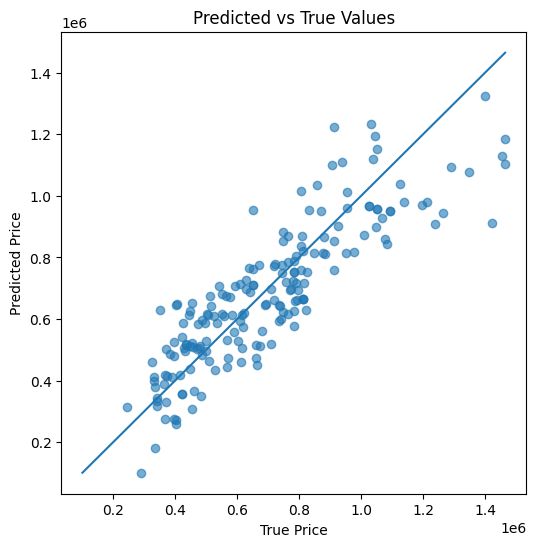

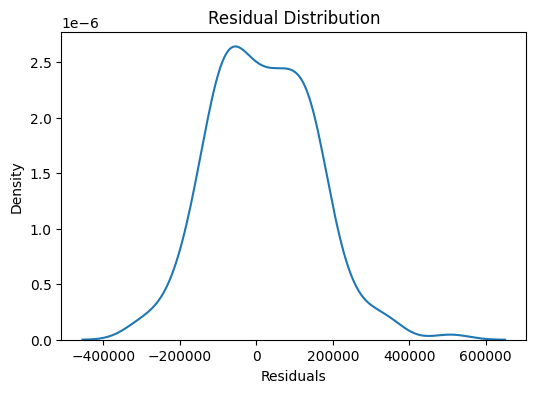

Test R^2: 0.7443813615632737
Test RMSE: 135103.61107410176


In [57]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

scaler = StandardScaler()
X_num_train_scaled = scaler.fit_transform(X_num_train)
X_num_test_scaled = scaler.transform(X_num_test)

poly = PolynomialFeatures(degree=3, include_bias=False)
X_num_train_poly = poly.fit_transform(X_num_train_scaled)
X_num_test_poly = poly.transform(X_num_test_scaled)

X_train_final = np.hstack([X_num_train_poly, X_cat_train.values])
X_test_final = np.hstack([X_num_test_poly, X_cat_test.values])

model = LinearRegression()
model.fit(X_train_final, y_train)

y_test_pred = model.predict(X_test_final)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test_pred, alpha=0.6)

min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("True Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs True Values")
plt.show()

residuals = y_test - y_test_pred

plt.figure(figsize=(6,4))
sns.kdeplot(residuals)
plt.title("Residual Distribution")
plt.xlabel("Residuals")
plt.show()

print("Test R^2:", r2_score(y_test, y_test_pred))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))

As the polynomial degree increases, training R^2 increases and training RMSE decreases, showing better fit on the training data. The test R^2 initially improves and RMSE decreases, but after degree 3 performance worsens due to overfitting. The test R^2 becomes negative at degree 6, indicating very poor generalization. The best model is degree 3, with test R^2 ≈ 0.7444 and RMSE = 135103.61. Compared to part 4, this is a slight improvement with higher R^2 and lower RMSE.


The predicted values generally align well along the diagonal, indicating that the model captures the overall relationship between features and price reasonably well. However, there is noticeable spread around the line, especially at higher prices, suggesting larger errors for more expensive cars. The residuals appear roughly bell-shaped and centered near zero, which indicates that the errors are fairly well-behaved. A strength of the model is its ability to capture nonlinear relationships and achieve strong predictive performance. A weakness is that it still struggles with extreme values and shows some variance, indicating imperfect fit and potential sensitivity to outliers.

**Q4.** Let's explore multiple linear regression in a two-variable case, to build more intuition about what is happening.

Suppose the model is
$$
\hat{y}_i = b_0 + b_1 z_{i1} + b_2 z_{i2}
$$
Assume that $z_{ij}$ is centered or de-meaned, so that $z_{ij} = x_{ij} - m_j$ where $m_j$ is the mean of variable $j$ and $x_{ij}$ is the original value of variable $j$ for observation $i$. Notice that this implies
$$
\dfrac{1}{N} \sum_{i=1}^N z_{ij} = 0
$$
which will simplify your calculations below substantially!

1. Write down the SSE for this model.
2. Take partial derivatives with respect to $b_0$, $b_1$, and $b_2$.
3. Verify that the average error is zero and $e \cdot z =0$ at the optimum, just as in the single linear regression case.
4. Show that the optimal intercept is $b_0^* = \bar{y}$. Eliminate $b_0^*$ from the remaining equations, and focus on $b_1$ and $b_2$.
5. Write your results as a matrix equation in the form "$Ab=C$". These are called the **normal equations**.
6. Divide both sides by $N$ and substitute $z_{ij} = x_{ij} - m_j$ back into your normal equations for $x_{ij}$. What is the matrix $A$? What is the vector $C$? Explain the intuition of your discovery.

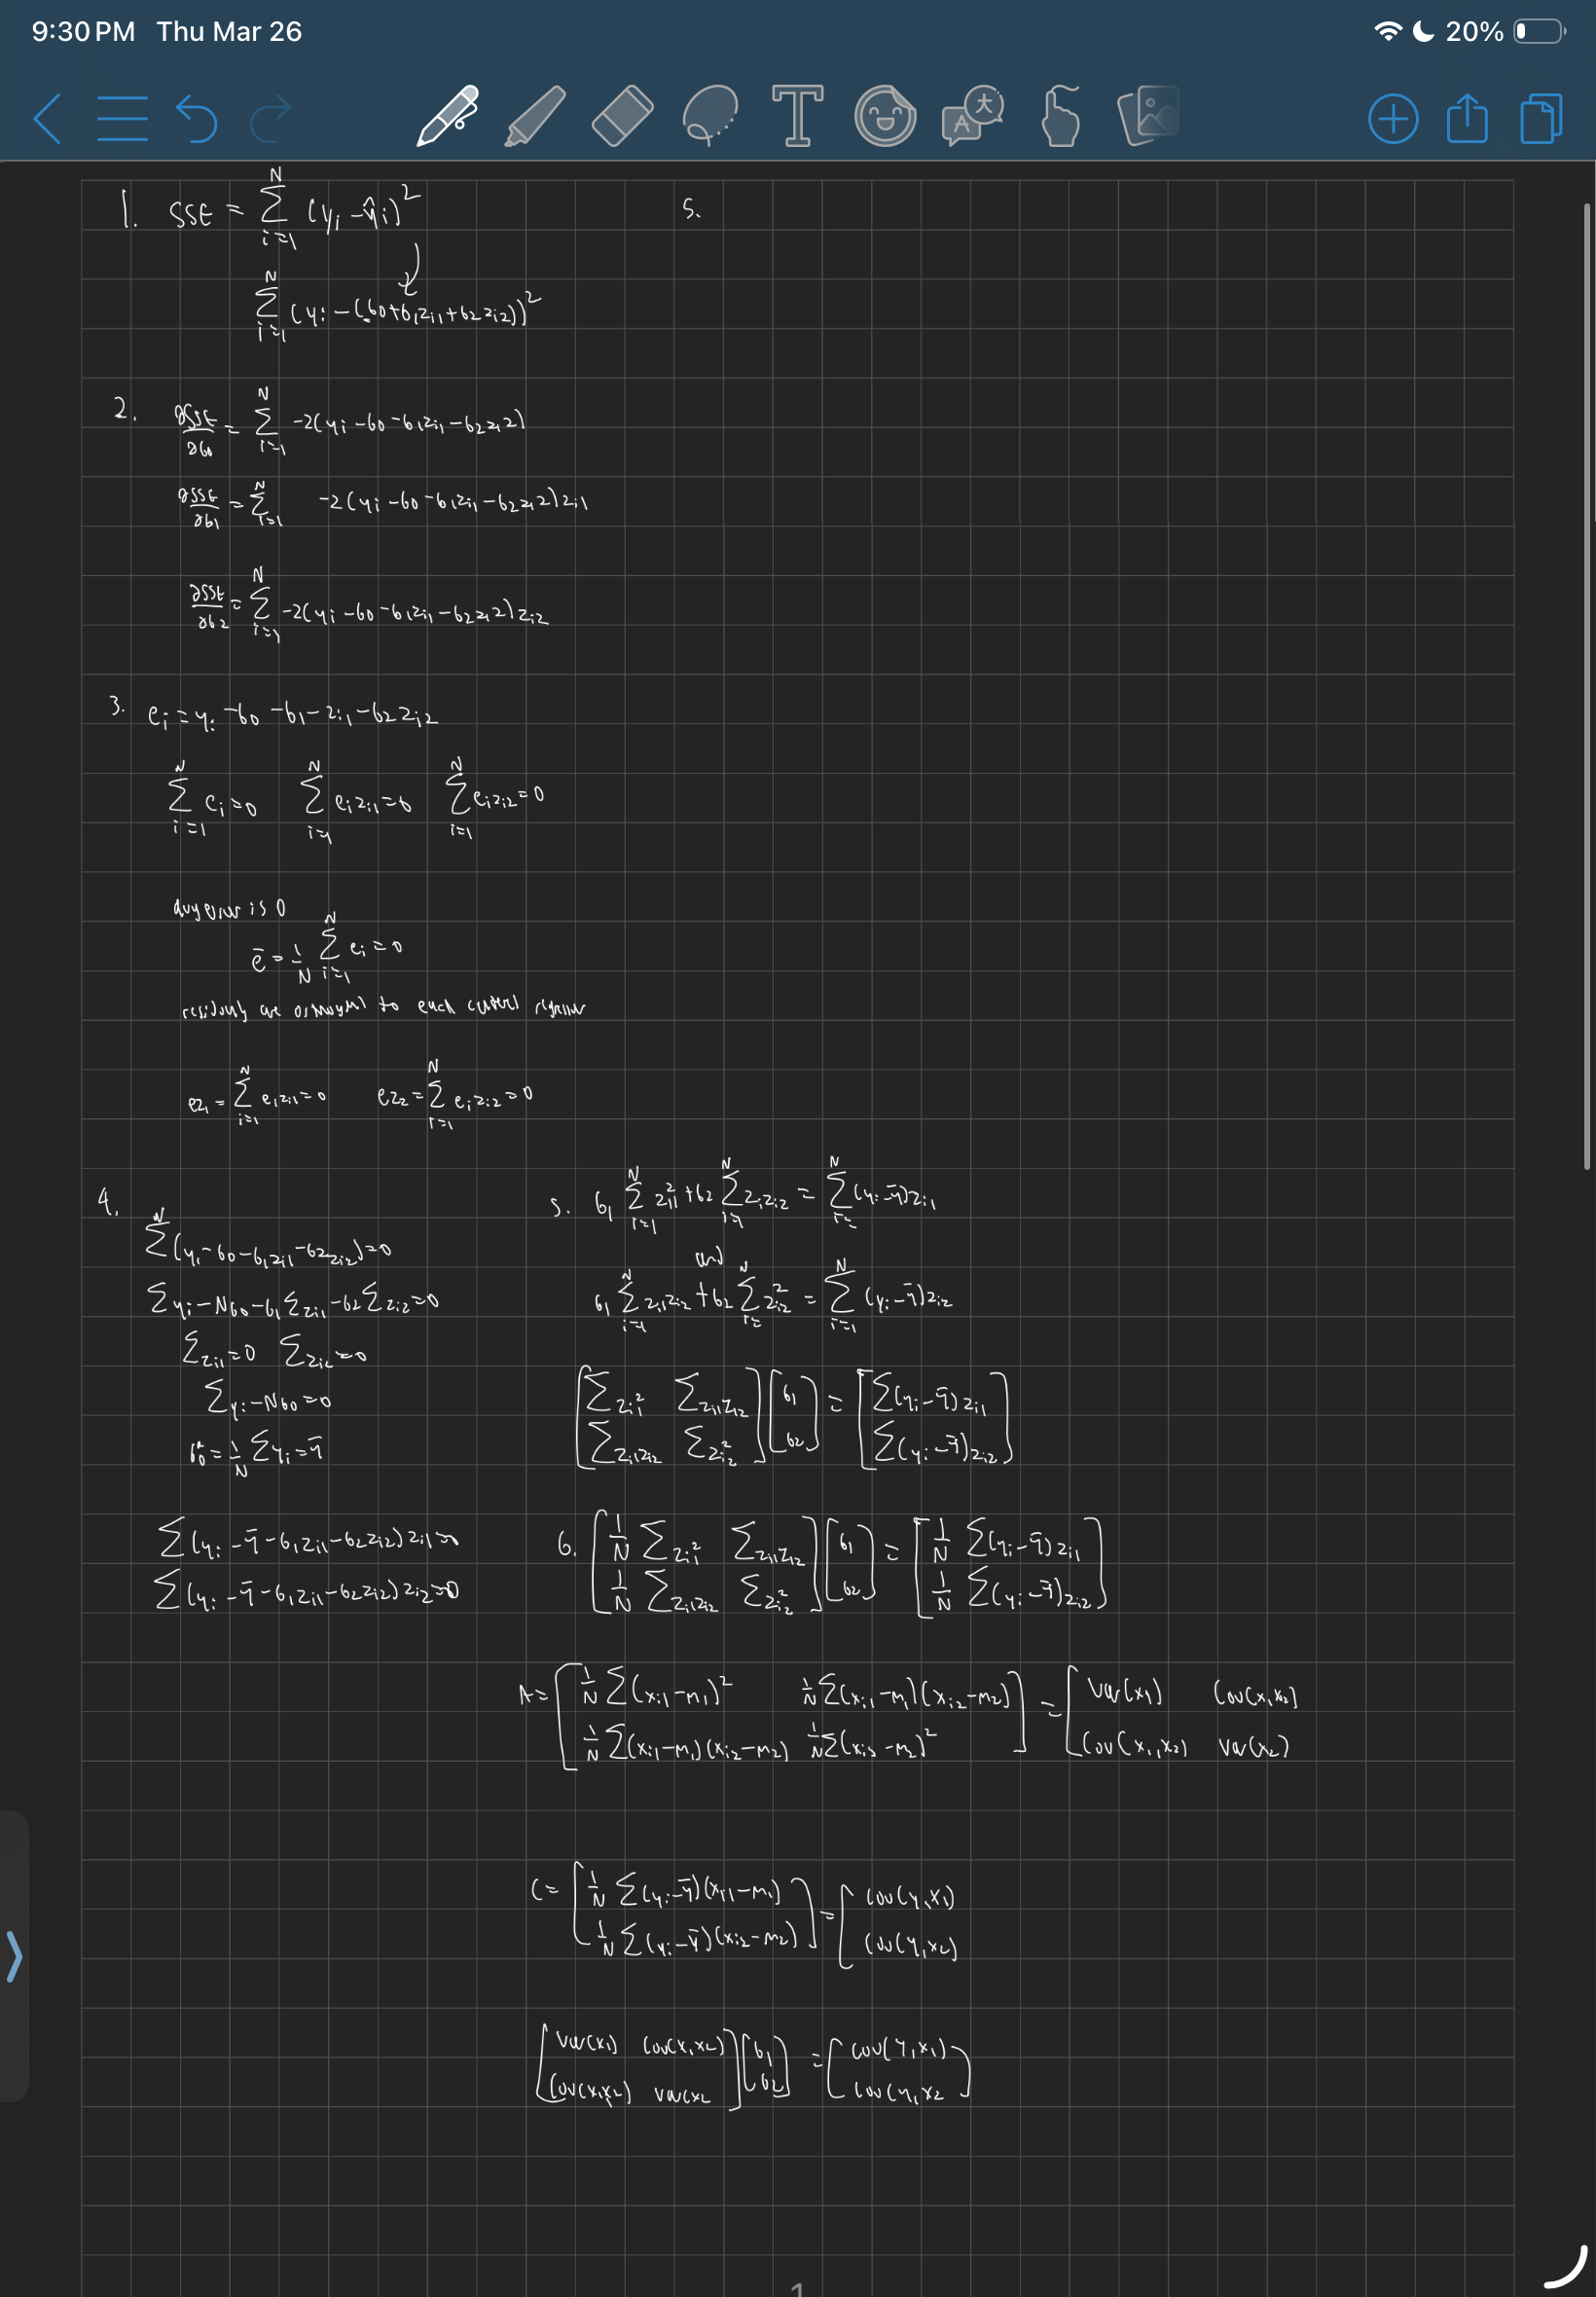